In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
os.getcwd()
os.listdir()

['.ipynb_checkpoints',
 'crisp-dm-reading.pdf',
 'ICU Patient Care Analysis Case Study.docx',
 'ICU_Patient_Care_Analysis.ipynb',
 'Rough Draft for ICU Patient Care Analysis Case Study.docx',
 'Show Your Work.pdf',
 '_39581d30f12b44a9a006970a4e853c4e_ICU-Patients',
 '_39581d30f12b44a9a006970a4e853c4e_ICU-Patients.zip']

In [3]:
# Below changes the os directory to icu where I run the icustays.csv.gz file

In [4]:
os.chdir(r"C:\Users\nefig\OneDrive\Documents\Data Science Related\Data Science Master's Program\Case Studies in Data Science\_39581d30f12b44a9a006970a4e853c4e_ICU-Patients\ICU Patients\data\raw\icu")

In [5]:
df = pd.read_csv("chartevents.csv.gz", compression='gzip')
df.head()

,subject_id,hadm_id,stay_id,caregiver_id,charttime,storetime,itemid,value,valuenum,valueuom,warning
0,10005817,20626031,32604416,6770.0,2132-12-16 00:00:00,2132-12-15 23:45:00,225054,On,NaN,NaN,0.0
1,10005817,20626031,32604416,6770.0,2132-12-16 00:00:00,2132-12-15 23:43:00,223769,100,100.0,%,0.0
2,10005817,20626031,32604416,6770.0,2132-12-16 00:00:00,2132-12-15 23:47:00,223956,Atrial demand,NaN,NaN,0.0
3,10005817,20626031,32604416,6770.0,2132-12-16 00:00:00,2132-12-15 23:47:00,224866,Yes,NaN,NaN,0.0
4,10005817,20626031,32604416,6770.0,2132-12-16 00:00:00,2132-12-15 23:45:00,227341,No,0.0,NaN,0.0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 668862 entries, 0 to 668861
Data columns (total 11 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   subject_id    668862 non-null  int64  
 1   hadm_id       668862 non-null  int64  
 2   stay_id       668862 non-null  int64  
 3   caregiver_id  644622 non-null  float64
 4   charttime     668862 non-null  object 
 5   storetime     667703 non-null  object 
 6   itemid        668862 non-null  int64  
 7   value         648132 non-null  object 
 8   valuenum      257474 non-null  float64
 9   valueuom      162571 non-null  object 
 10  warning       667703 non-null  float64
dtypes: float64(3), int64(4), object(4)
memory usage: 56.1+ MB


In [7]:
chartevents = pd.read_csv("chartevents.csv.gz", compression="gzip", nrows=100000)
items = pd.read_csv("d_items.csv.gz", compression="gzip")

# merge to see names
merged = chartevents.merge(items, on="itemid", how="left")

merged[['itemid', 'label']].drop_duplicates().head()

,itemid,label
0,225054,Anti Embolic Device Status
1,223769,O2 Saturation Pulseoxymetry Alarm - High
2,223956,Temporary Pacemaker Mode
3,224866,Temporary Atrial Capture
4,227341,History of falling (within 3 mnths)


In [8]:
icustays = pd.read_csv("icustays.csv.gz", compression='gzip')
icustays.head()

,subject_id,hadm_id,stay_id,first_careunit,last_careunit,intime,outtime,los
0,10018328,23786647,31269608,Neuro Stepdown,Neuro Stepdown,2154-04-24 23:03:44,2154-05-02 15:55:21,7.702512
1,10020187,24104168,37509585,Neuro Surgical Intensive Care Unit (Neuro SICU),Neuro Stepdown,2169-01-15 04:56:00,2169-01-20 15:47:50,5.452662
2,10020187,26842957,32554129,Neuro Intermediate,Neuro Intermediate,2170-02-24 18:18:46,2170-02-25 15:15:26,0.872685
3,10012853,27882036,31338022,Trauma SICU (TSICU),Trauma SICU (TSICU),2176-11-26 02:34:49,2176-11-29 20:58:54,3.766725
4,10020740,25826145,32145159,Trauma SICU (TSICU),Trauma SICU (TSICU),2150-06-03 20:12:32,2150-06-04 21:05:58,1.037106


In [9]:
icustays.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 140 entries, 0 to 139
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   subject_id      140 non-null    int64  
 1   hadm_id         140 non-null    int64  
 2   stay_id         140 non-null    int64  
 3   first_careunit  140 non-null    object 
 4   last_careunit   140 non-null    object 
 5   intime          140 non-null    object 
 6   outtime         140 non-null    object 
 7   los             140 non-null    float64
dtypes: float64(1), int64(3), object(4)
memory usage: 8.9+ KB


In [10]:
df = pd.read_csv("datetimeevents.csv.gz", compression='gzip')
df.head()

,subject_id,hadm_id,stay_id,caregiver_id,charttime,storetime,itemid,value,valueuom,warning
0,10002428,23473524,35479615,29441,2156-05-15 10:50:00,2156-05-15 10:50:00,225343,2156-05-11 00:00:00,Date,0
1,10002428,23473524,35479615,29441,2156-05-15 10:50:00,2156-05-15 10:50:00,225348,2156-05-11 00:00:00,Date,0
2,10002428,23473524,35479615,29441,2156-05-15 10:50:00,2156-05-15 10:50:00,225345,2156-05-14 09:00:00,Date and Time,0
3,10002428,23473524,35479615,29441,2156-05-15 09:00:00,2156-05-15 10:51:00,224186,2156-05-15 09:00:00,Date and Time,0
4,10002428,23473524,35479615,29441,2156-05-15 09:00:00,2156-05-15 10:51:00,224187,2156-05-15 10:50:00,Date,0


In [11]:
# Below changes the os directory to hosp where I run the admissions.csv.gz file

In [12]:
os.chdir(r"C:\Users\nefig\OneDrive\Documents\Data Science Related\Data Science Master's Program\Case Studies in Data Science\_39581d30f12b44a9a006970a4e853c4e_ICU-Patients\ICU Patients\data\raw\hosp")

In [13]:
df = pd.read_csv("admissions.csv.gz", compression='gzip')
df.head()

,subject_id,hadm_id,admittime,dischtime,deathtime,admission_type,admit_provider_id,admission_location,discharge_location,insurance,language,marital_status,race,edregtime,edouttime,hospital_expire_flag
0,10004235,24181354,2196-02-24 14:38:00,2196-03-04 14:02:00,NaN,URGENT,P03YMR,TRANSFER FROM HOSPITAL,SKILLED NURSING FACILITY,Medicaid,ENGLISH,SINGLE,BLACK/CAPE VERDEAN,2196-02-24 12:15:00,2196-02-24 17:07:00,0
1,10009628,25926192,2153-09-17 17:08:00,2153-09-25 13:20:00,NaN,URGENT,P41R5N,TRANSFER FROM HOSPITAL,HOME HEALTH CARE,Medicaid,?,MARRIED,HISPANIC/LATINO - PUERTO RICAN,NaN,NaN,0
2,10018081,23983182,2134-08-18 02:02:00,2134-08-23 19:35:00,NaN,URGENT,P233F6,TRANSFER FROM HOSPITAL,SKILLED NURSING FACILITY,Medicare,ENGLISH,MARRIED,WHITE,2134-08-17 16:24:00,2134-08-18 03:15:00,0
3,10006053,22942076,2111-11-13 23:39:00,2111-11-15 17:20:00,2111-11-15 17:20:00,URGENT,P38TI6,TRANSFER FROM HOSPITAL,DIED,Medicaid,ENGLISH,NaN,UNKNOWN,NaN,NaN,1
4,10031404,21606243,2113-08-04 18:46:00,2113-08-06 20:57:00,NaN,URGENT,P07HDB,TRANSFER FROM HOSPITAL,HOME,Other,ENGLISH,WIDOWED,WHITE,NaN,NaN,0


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 275 entries, 0 to 274
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   subject_id            275 non-null    int64 
 1   hadm_id               275 non-null    int64 
 2   admittime             275 non-null    object
 3   dischtime             275 non-null    object
 4   deathtime             15 non-null     object
 5   admission_type        275 non-null    object
 6   admit_provider_id     275 non-null    object
 7   admission_location    275 non-null    object
 8   discharge_location    233 non-null    object
 9   insurance             275 non-null    object
 10  language              275 non-null    object
 11  marital_status        263 non-null    object
 12  race                  275 non-null    object
 13  edregtime             182 non-null    object
 14  edouttime             182 non-null    object
 15  hospital_expire_flag  275 non-null    in

In [15]:
patients = pd.read_csv("patients.csv.gz", compression='gzip')
patients.head()

,subject_id,gender,anchor_age,anchor_year,anchor_year_group,dod
0,10014729,F,21,2125,2011 - 2013,NaN
1,10003400,F,72,2134,2011 - 2013,2137-09-02
2,10002428,F,80,2155,2011 - 2013,NaN
3,10032725,F,38,2143,2011 - 2013,2143-03-30
4,10027445,F,48,2142,2011 - 2013,2146-02-09


In [16]:
patients.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   subject_id         100 non-null    int64 
 1   gender             100 non-null    object
 2   anchor_age         100 non-null    int64 
 3   anchor_year        100 non-null    int64 
 4   anchor_year_group  100 non-null    object
 5   dod                31 non-null     object
dtypes: int64(3), object(3)
memory usage: 4.8+ KB


In [17]:
labevents = pd.read_csv("labevents.csv.gz", compression="gzip", nrows=100000)   # sample first

d_labitems = pd.read_csv("d_labitems.csv.gz", compression="gzip")

In [18]:
labs_merged = labevents.merge(d_labitems, on="itemid", how="left")

In [19]:
labs_merged[['itemid','label']].drop_duplicates().head(40)

,itemid,label
0,51277,RDW
1,51279,Red Blood Cells
2,52172,RDW-SD
3,51301,White Blood Cells
4,51249,MCHC
5,51221,Hematocrit
6,51222,Hemoglobin
7,51265,Platelet Count
8,51250,MCV
9,51248,MCH


In [20]:
# Example of Lactate labs only

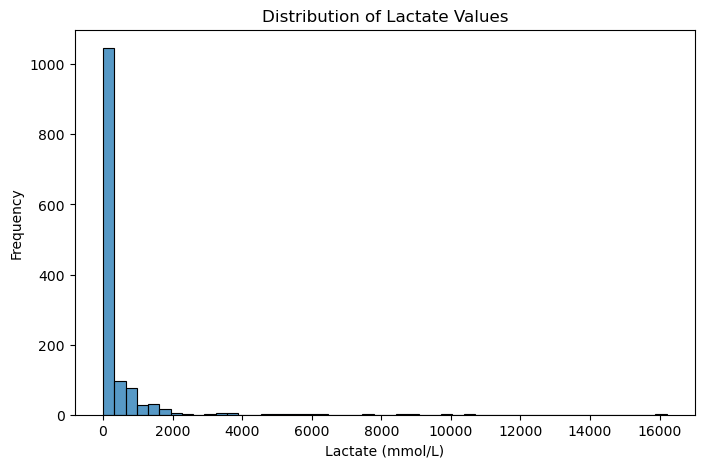

count     1328.000000
mean       347.287651
std        977.449535
min          0.500000
25%          1.800000
50%          8.450000
75%        266.000000
max      16200.000000
Name: valuenum, dtype: float64


In [21]:
lactate = labs_merged[labs_merged['label'].str.contains('lactate', case=False)]

plt.figure(figsize=(8,5))
sns.histplot(lactate['valuenum'].dropna(), bins=50)
plt.title("Distribution of Lactate Values")
plt.xlabel("Lactate (mmol/L)")
plt.ylabel("Frequency")
plt.show()

print(lactate['valuenum'].describe())

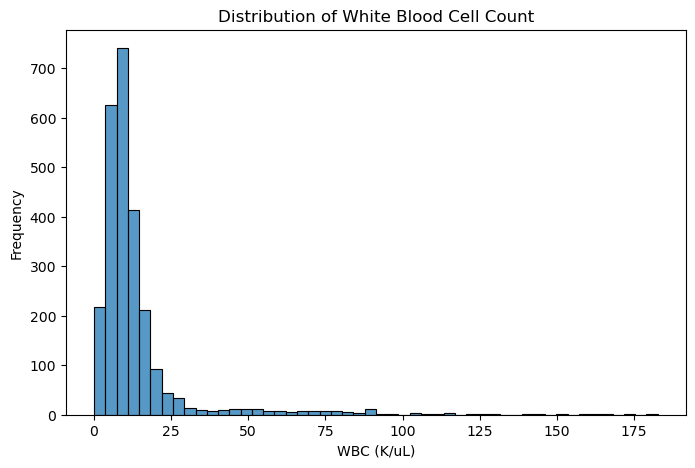

count    2550.000000
mean       13.545020
std        17.064421
min         0.100000
25%         6.400000
50%         9.300000
75%        13.500000
max       182.600000
Name: valuenum, dtype: float64


In [22]:
wbc = labs_merged[labs_merged['label'].str.contains('white blood cell', case=False, na=False)
]

plt.figure(figsize=(8,5))
sns.histplot(wbc['valuenum'].dropna(), bins=50)
plt.title("Distribution of White Blood Cell Count")
plt.xlabel("WBC (K/uL)")
plt.ylabel("Frequency")
plt.show()

print(wbc['valuenum'].describe())


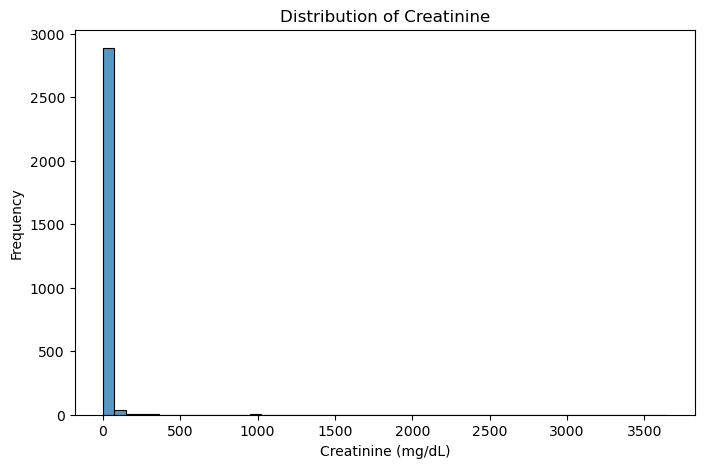

count    2946.000000
mean        8.705193
std        99.025183
min         0.100000
25%         0.800000
50%         1.100000
75%         1.900000
max      3643.000000
Name: valuenum, dtype: float64


In [23]:
creatinine = labs_merged[labs_merged['label'].str.contains('creatinine', case=False, na=False)
]

plt.figure(figsize=(8,5))
sns.histplot(creatinine['valuenum'].dropna(), bins=50)
plt.title("Distribution of Creatinine")
plt.xlabel("Creatinine (mg/dL)")
plt.ylabel("Frequency")
plt.show()

print(creatinine['valuenum'].describe())


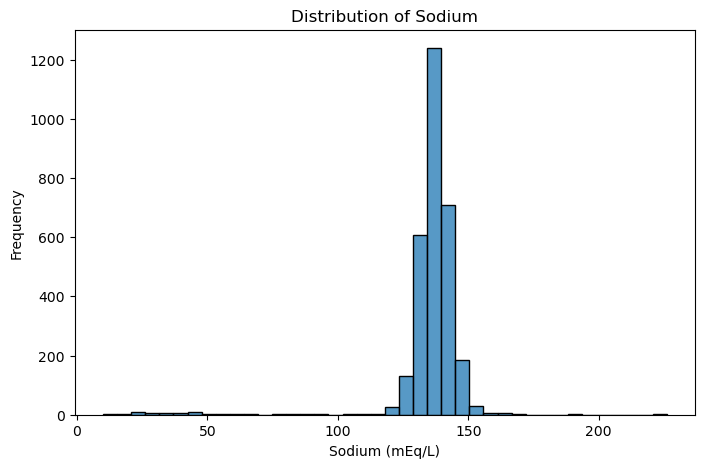

count    2996.000000
mean      135.609146
std        14.577561
min        10.000000
25%       134.000000
50%       137.000000
75%       140.000000
max       226.000000
Name: valuenum, dtype: float64


In [24]:
sodium = labs_merged[labs_merged['label'].str.contains('sodium', case=False, na=False)
]

plt.figure(figsize=(8,5))
sns.histplot(sodium['valuenum'].dropna(), bins=40)
plt.title("Distribution of Sodium")
plt.xlabel("Sodium (mEq/L)")
plt.ylabel("Frequency")
plt.show()

print(sodium['valuenum'].describe())

In [25]:
#Age Distribution (Demographic Driver)

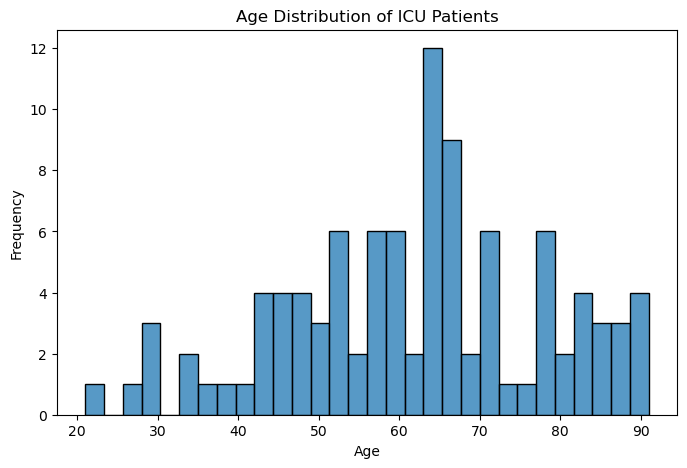

count    100.00000
mean      61.75000
std       16.16979
min       21.00000
25%       51.75000
50%       63.00000
75%       72.00000
max       91.00000
Name: anchor_age, dtype: float64


In [26]:
plt.figure(figsize=(8,5))
sns.histplot(patients['anchor_age'], bins=30)
plt.title("Age Distribution of ICU Patients")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

print(patients['anchor_age'].describe())

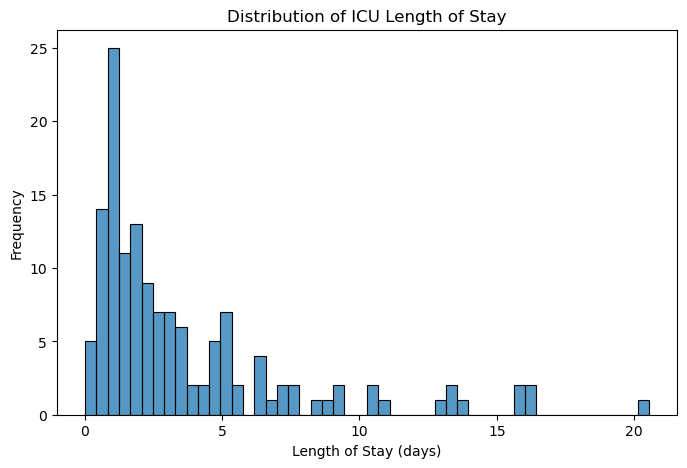

count    140.000000
mean       3.679379
std        3.896354
min        0.023727
25%        1.170663
50%        2.155093
75%        4.907749
max       20.528681
Name: los, dtype: float64


In [27]:
plt.figure(figsize=(8,5))
sns.histplot(icustays['los'], bins=50)
plt.title("Distribution of ICU Length of Stay")
plt.xlabel("Length of Stay (days)")
plt.ylabel("Frequency")
plt.show()

print(icustays['los'].describe())

In [28]:
# Elevated early lactate levels may predict ICU utilization of resources

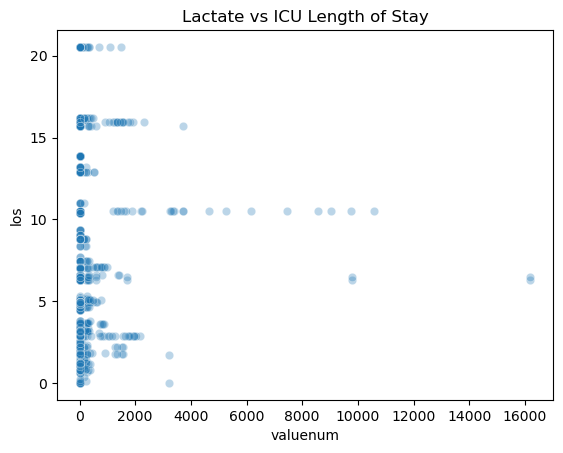

Correlation: 0.05365689699721663


In [29]:
merged = lactate.merge(icustays[['subject_id','hadm_id','los']],
                       on=['subject_id','hadm_id'])

sns.scatterplot(data=merged, x='valuenum', y='los', alpha=0.3)
plt.title("Lactate vs ICU Length of Stay")
plt.show()

print("Correlation:", merged['valuenum'].corr(merged['los']))

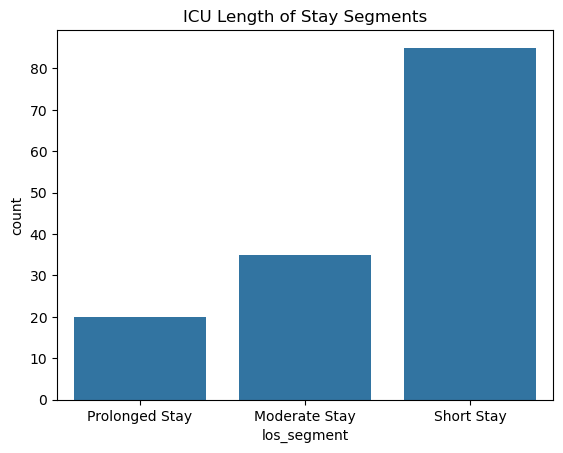

In [30]:
icustays['los_segment'] = np.where(
    icustays['los'] <= 3, 'Short Stay',
    np.where(icustays['los'] <= 7, 'Moderate Stay', 'Prolonged Stay')
)

sns.countplot(x='los_segment', data=icustays)
plt.title("ICU Length of Stay Segments")
plt.show()

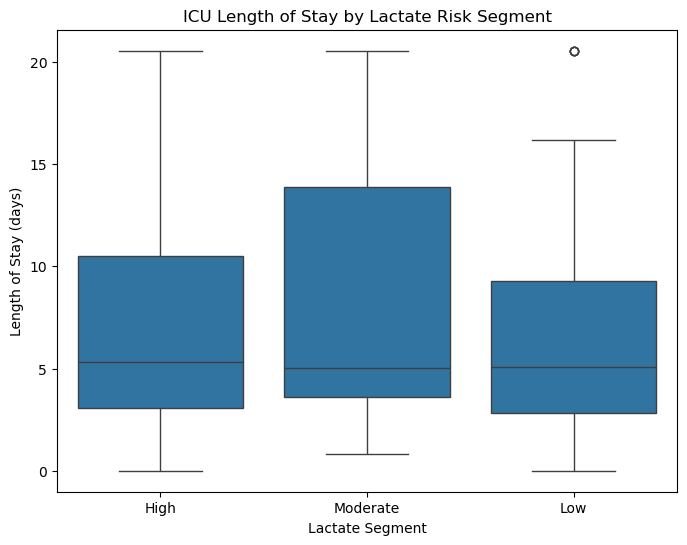

In [31]:
import numpy as np

merged['lactate_segment'] = np.where(
    merged['valuenum'] < 2, 'Low',
    np.where(merged['valuenum'] <= 4, 'Moderate', 'High')
)

plt.figure(figsize=(8,6))
sns.boxplot(data=merged, x='lactate_segment', y='los')
plt.title("ICU Length of Stay by Lactate Risk Segment")
plt.xlabel("Lactate Segment")
plt.ylabel("Length of Stay (days)")
plt.show()


Invalid ages: 0


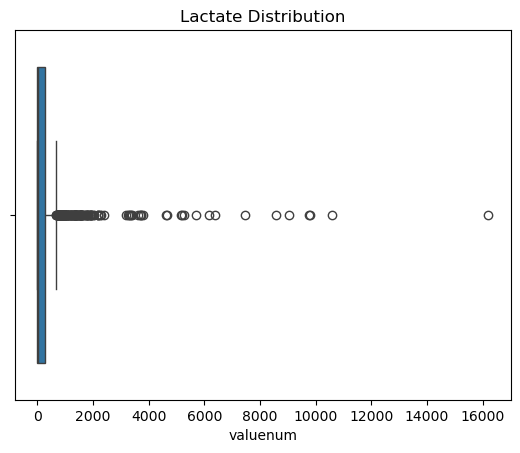

In [32]:
# Age should be 0-120
invalid_age = patients[ (patients['anchor_age'] < 0) | (patients['anchor_age'] > 120) ]
print(f"Invalid ages: {len(invalid_age)}")

# Lab values example: lactate
lactate = labs_merged[labs_merged['label'].str.contains('lactate', case=False)]
sns.boxplot(x=lactate['valuenum'])
plt.title("Lactate Distribution")
plt.show()

In [33]:
# Check ICU time consistency
invalid_times = icustays[ icustays['intime'] >= icustays['outtime'] ]
len(invalid_times)

0